# vsini Spatial Maps

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.style import setup_style
from src.spatial import vsini_maps_for_plane, vmag_maps_for_plane
from src.plotting import plot_vsini_bootstrap_panel, plot_vmag_bootstrap_panel

setup_style(fontsize=12)

ROOT = Path("../")
FIG_DIR = ROOT / "figures"

# Grid parameters
UL = 150  # half-extent [pc]
TC = 20  # cell size [pc]
N_BOOT = 1000  # bootstrap resamples
SEED = 42
CMAP_VMAX = 20
VMAG_CMAP_VMIN = 4.0
VMAG_CMAP_VMAX = 9.0

## 2. Load data

In [3]:
df_F = pd.read_csv(ROOT / "data" / "processed" / "gcs-Fstars-complete.csv")
df_G = pd.read_csv(ROOT / "data" / "processed" / "gcs-Gstars-complete.csv")
df_all = pd.read_csv(ROOT / "data" / "processed" / "gcs-allstars-complete.csv")

## 3. Compute grid statistics (original + bootstrap)

In [4]:
print("Computing maps for ALL stars")
maps_all_XY = vsini_maps_for_plane(
    df_all, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_all_XY_ww = vsini_maps_for_plane(
    df_all, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

maps_all_XZ = vsini_maps_for_plane(
    df_all, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_all_XZ_ww = vsini_maps_for_plane(
    df_all, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

maps_all_ZY = vsini_maps_for_plane(
    df_all, "ZY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_all_ZY_ww = vsini_maps_for_plane(
    df_all, "ZY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

Computing maps for ALL stars


In [5]:
print("Computing maps for F-type stars")

maps_F_XY = vsini_maps_for_plane(
    df_F, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_F_XY_ww = vsini_maps_for_plane(
    df_F, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

maps_F_XZ = vsini_maps_for_plane(
    df_F, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_F_XZ_ww = vsini_maps_for_plane(
    df_F, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

Computing maps for F-type stars


In [6]:
print("Computing maps for G-type stars")

maps_G_XY = vsini_maps_for_plane(
    df_G, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_G_XY_ww = vsini_maps_for_plane(
    df_G, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

maps_G_XZ = vsini_maps_for_plane(
    df_G, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)
maps_G_XZ_ww = vsini_maps_for_plane(
    df_G, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
)

Computing maps for G-type stars


## All stars, XY plane

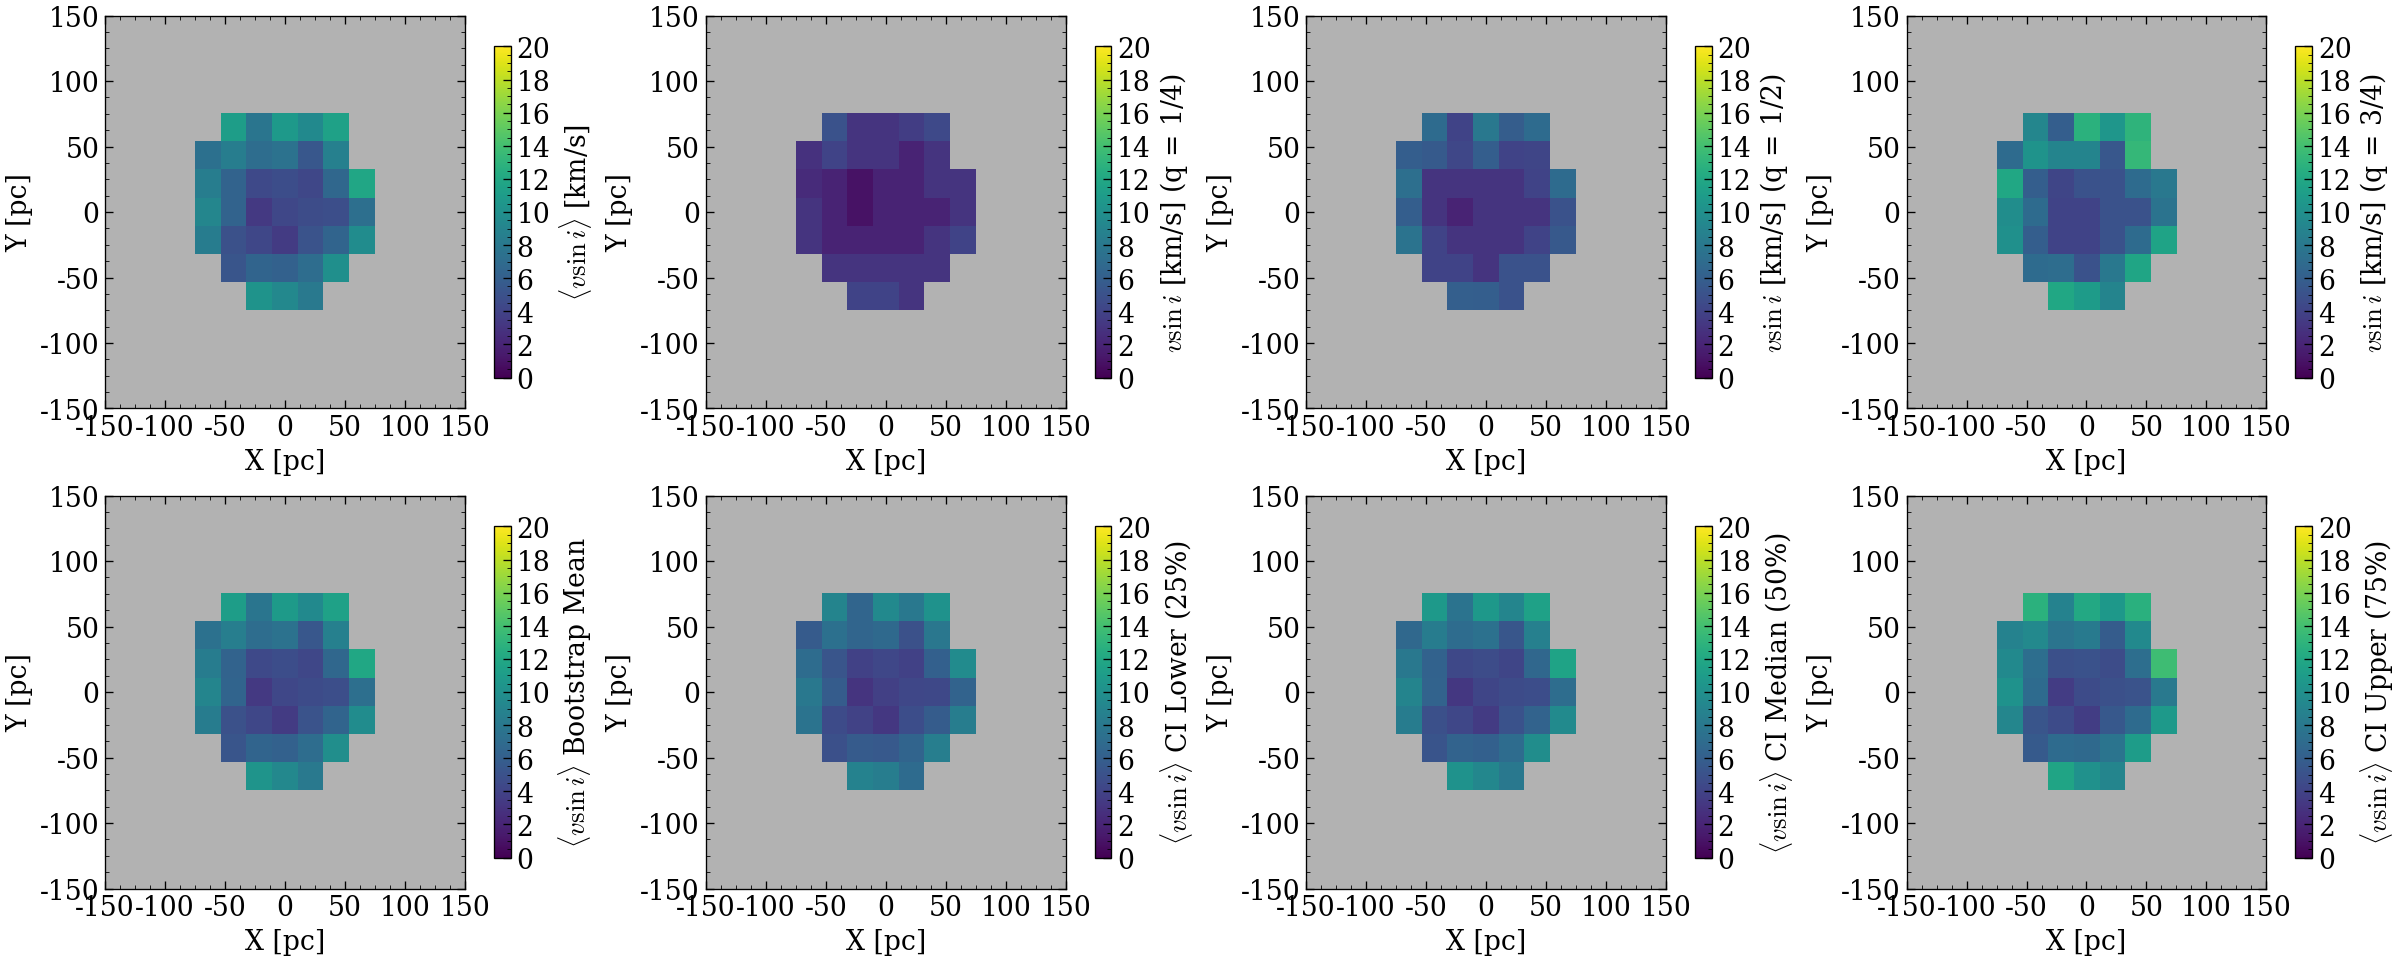

In [7]:
# WITH WEIGHTS
fig3, _ = plot_vsini_bootstrap_panel(
    original=maps_all_XY["original"],
    bootstrap=maps_all_XY["bootstrap"],
    plane="XY",
    ul=UL,
    cmap="viridis",
    vmax=CMAP_VMAX,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
# fig3.savefig(FIG_DIR / "vsini_all_XY.pdf")
plt.show()

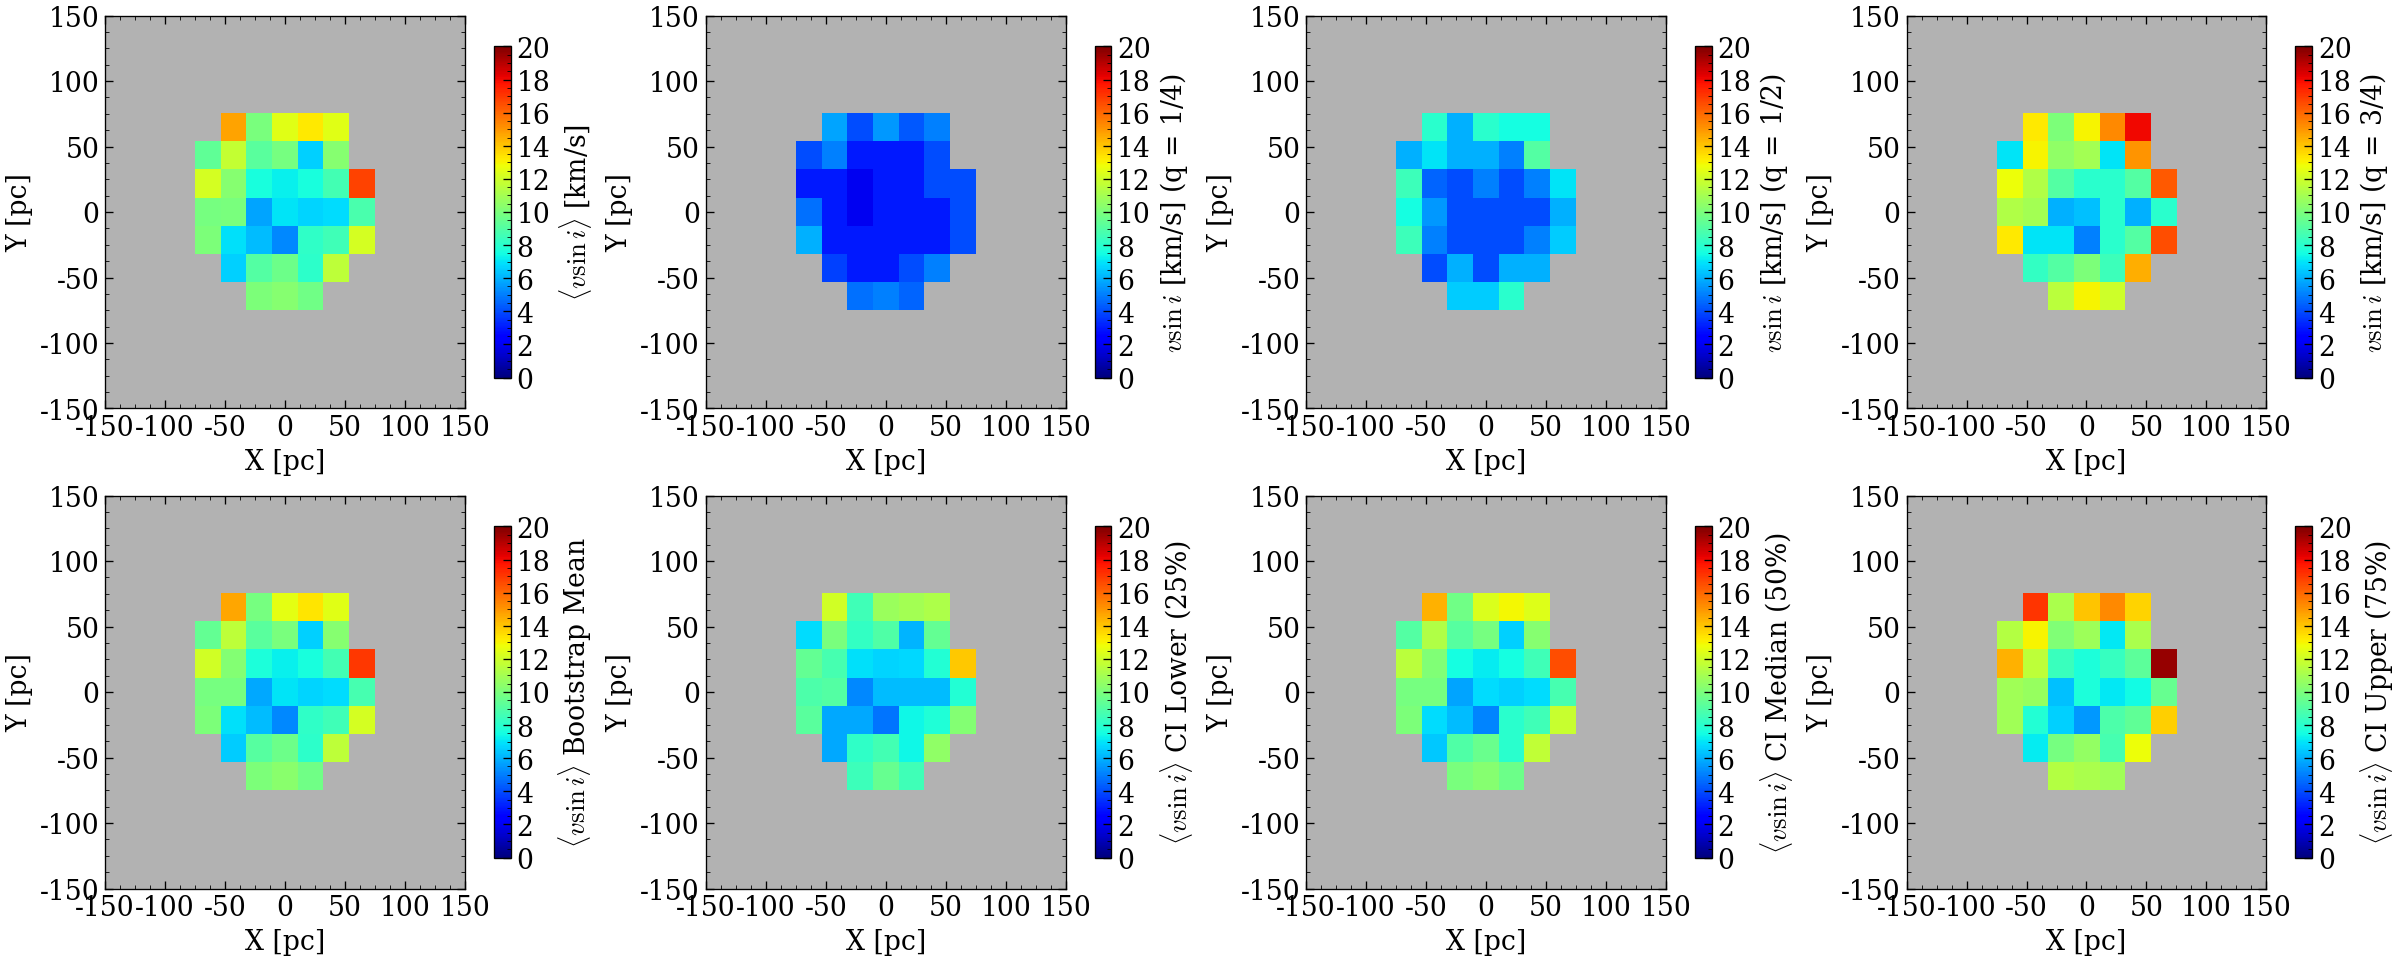

In [8]:
# WITHOUT WEIGHTS
fig3, _ = plot_vsini_bootstrap_panel(
    original=maps_all_XY_ww["original"],
    bootstrap=maps_all_XY_ww["bootstrap"],
    plane="XY",
    ul=UL,
    method='none',
    cmap="jet",
    vmax=CMAP_VMAX,
    raw_cells = True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
# fig3.savefig(FIG_DIR / "vsini_all_XY_without_weights.pdf")
plt.show()

## 5. All stars, XZ plane

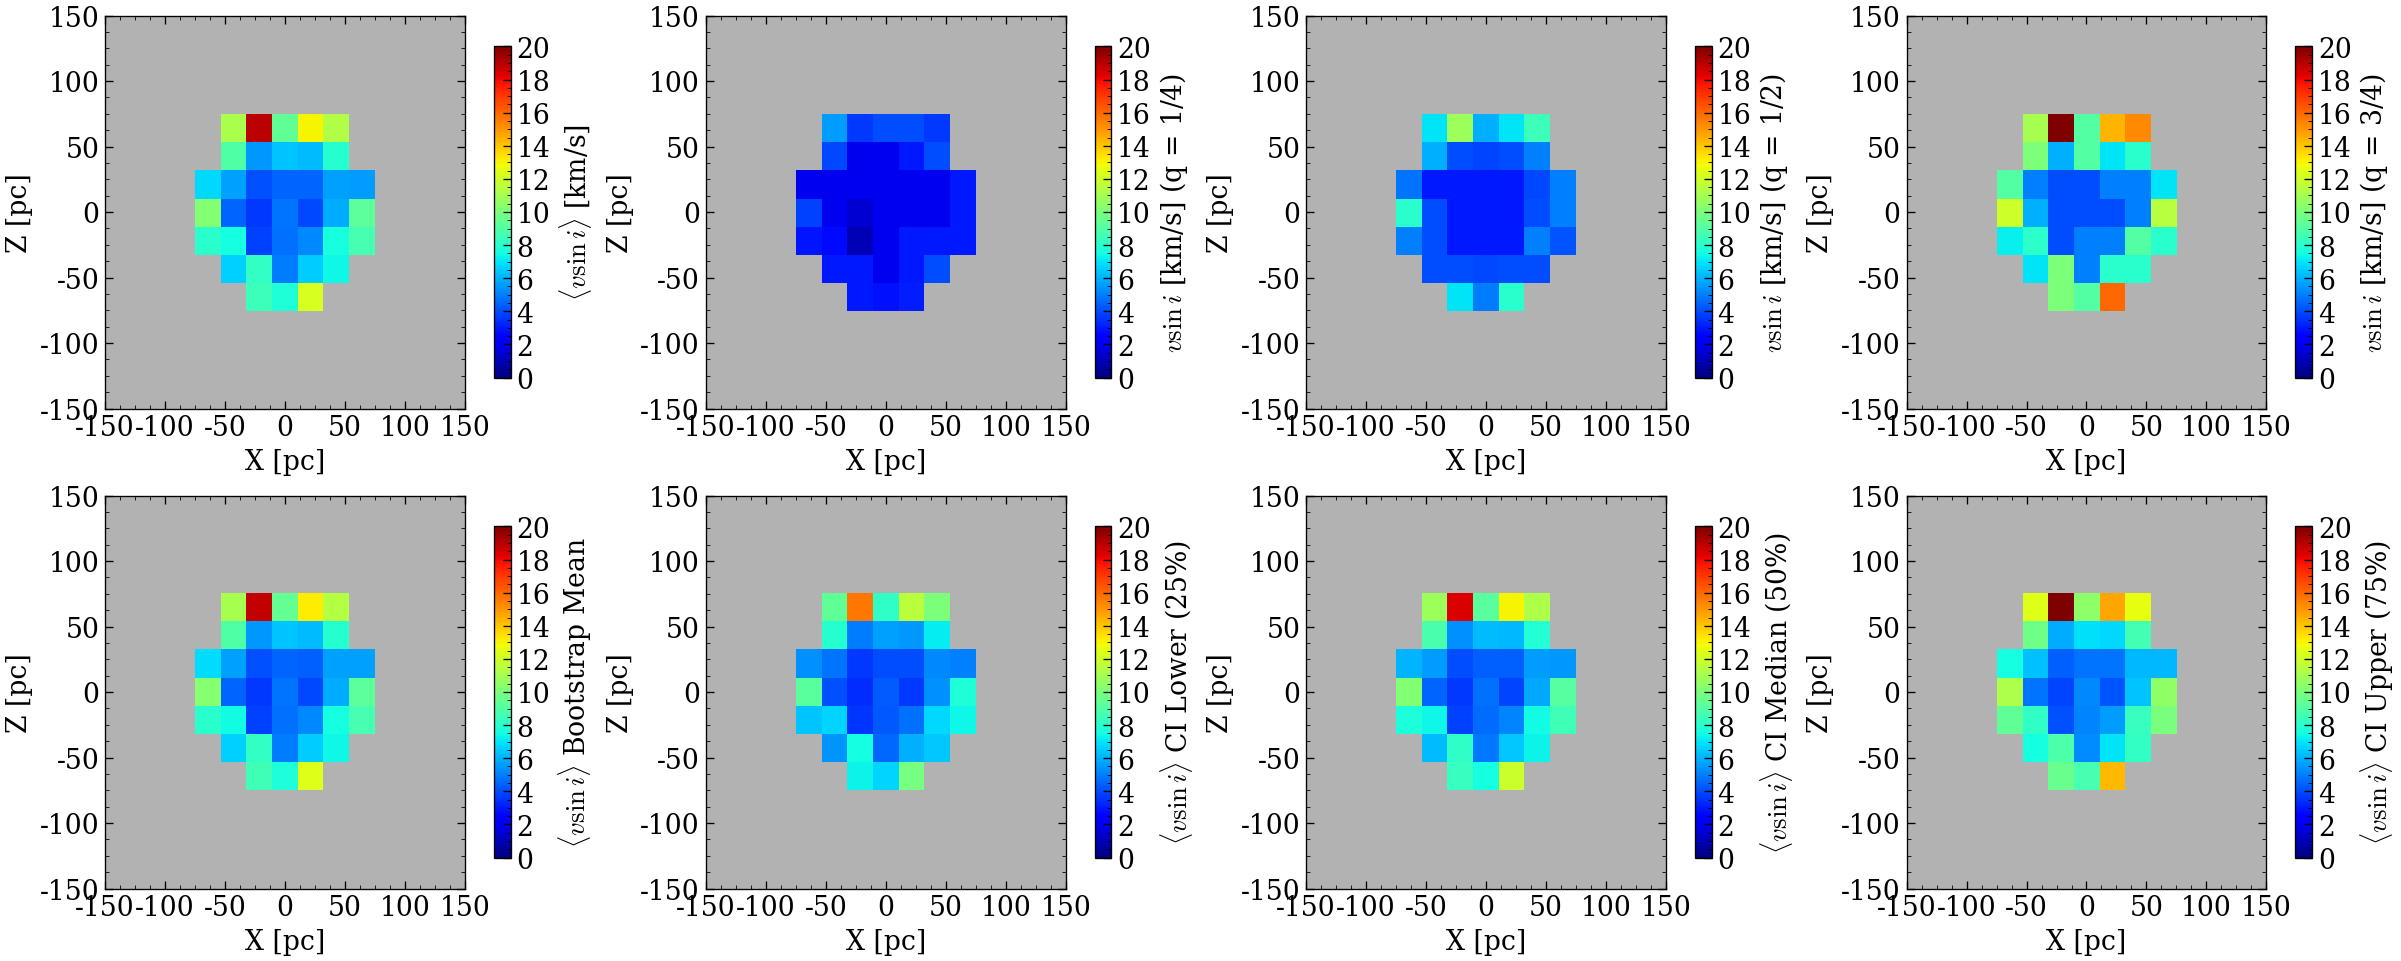

In [50]:
fig6, _ = plot_vsini_bootstrap_panel(
    original=maps_all_XZ["original"],
    bootstrap=maps_all_XZ["bootstrap"],
    plane="XZ",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=CMAP_VMAX,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig6.savefig(FIG_DIR / "vsini_all_XZ.pdf")
plt.show()

## 6. All stars, ZY plane

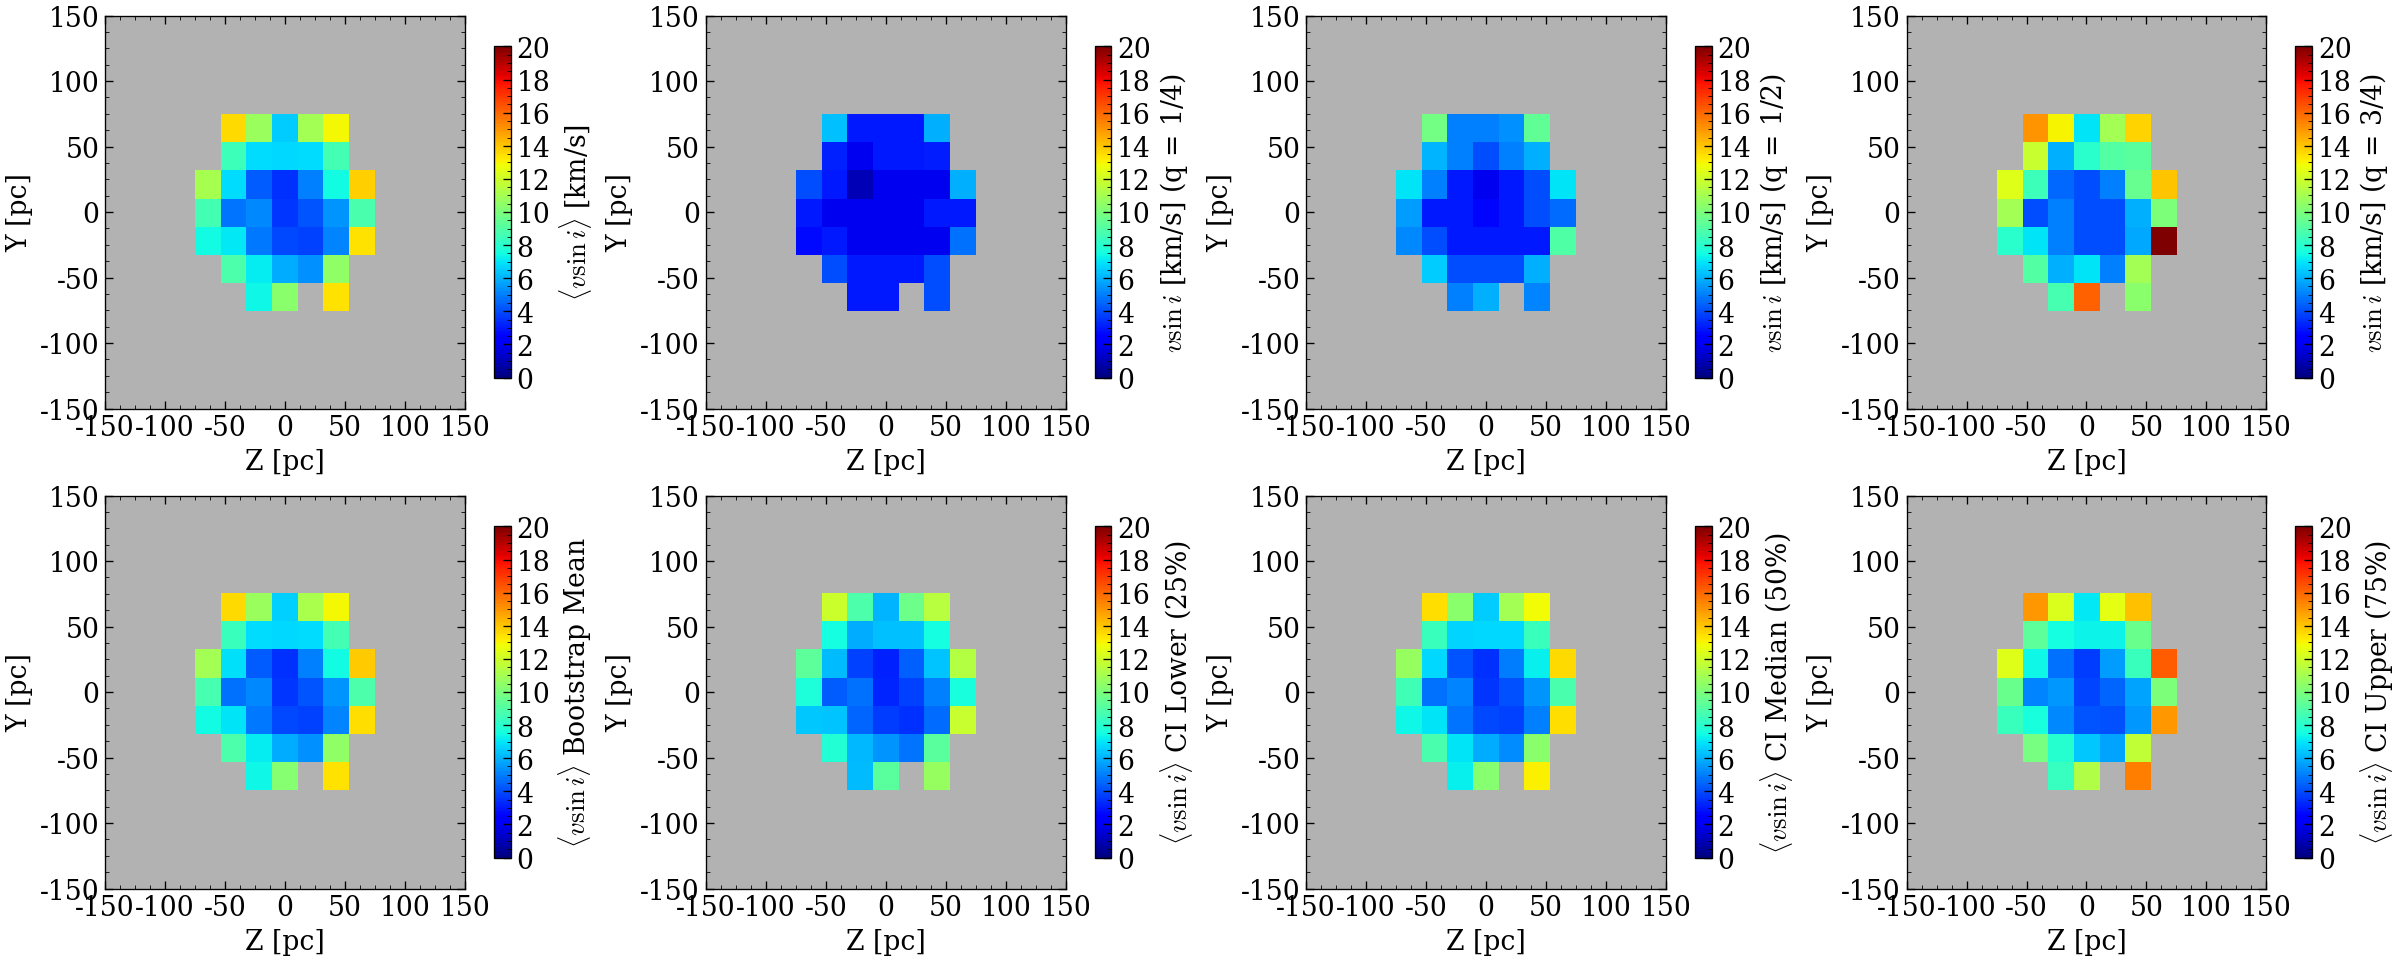

In [51]:
fig7, _ = plot_vsini_bootstrap_panel(
    original=maps_all_ZY["original"],
    bootstrap=maps_all_ZY["bootstrap"],
    plane="ZY",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=CMAP_VMAX,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig7.savefig(FIG_DIR / "vsini_all_ZY.pdf")
plt.show()

## 7. F-type stars, XY plane

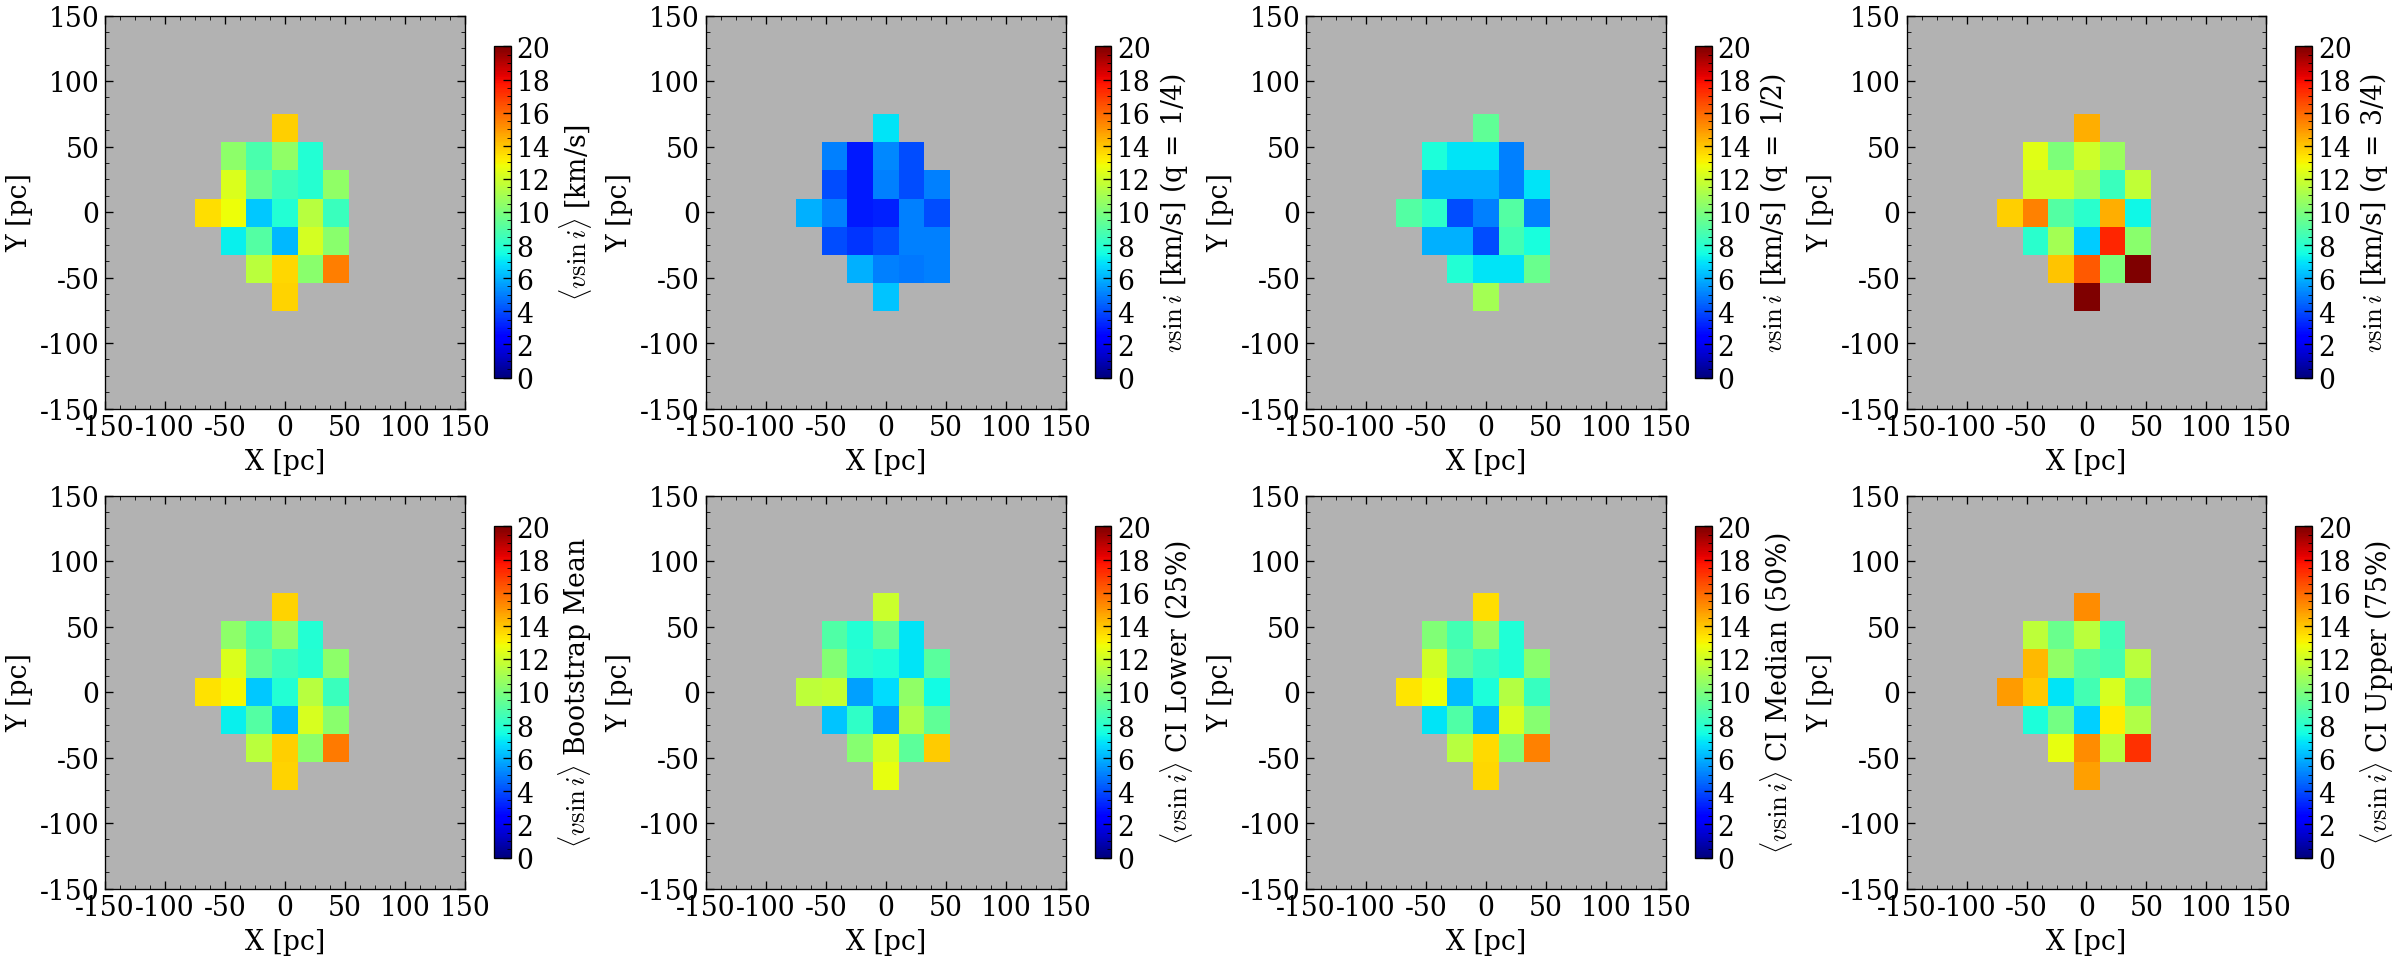

In [52]:
fig8, _ = plot_vsini_bootstrap_panel(
    original=maps_F_XY["original"],
    bootstrap=maps_F_XY["bootstrap"],
    plane="XY",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=CMAP_VMAX,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig8.savefig(FIG_DIR / "vsini_F_XY.pdf")
plt.show()

## 8. F-type stars, XZ plane

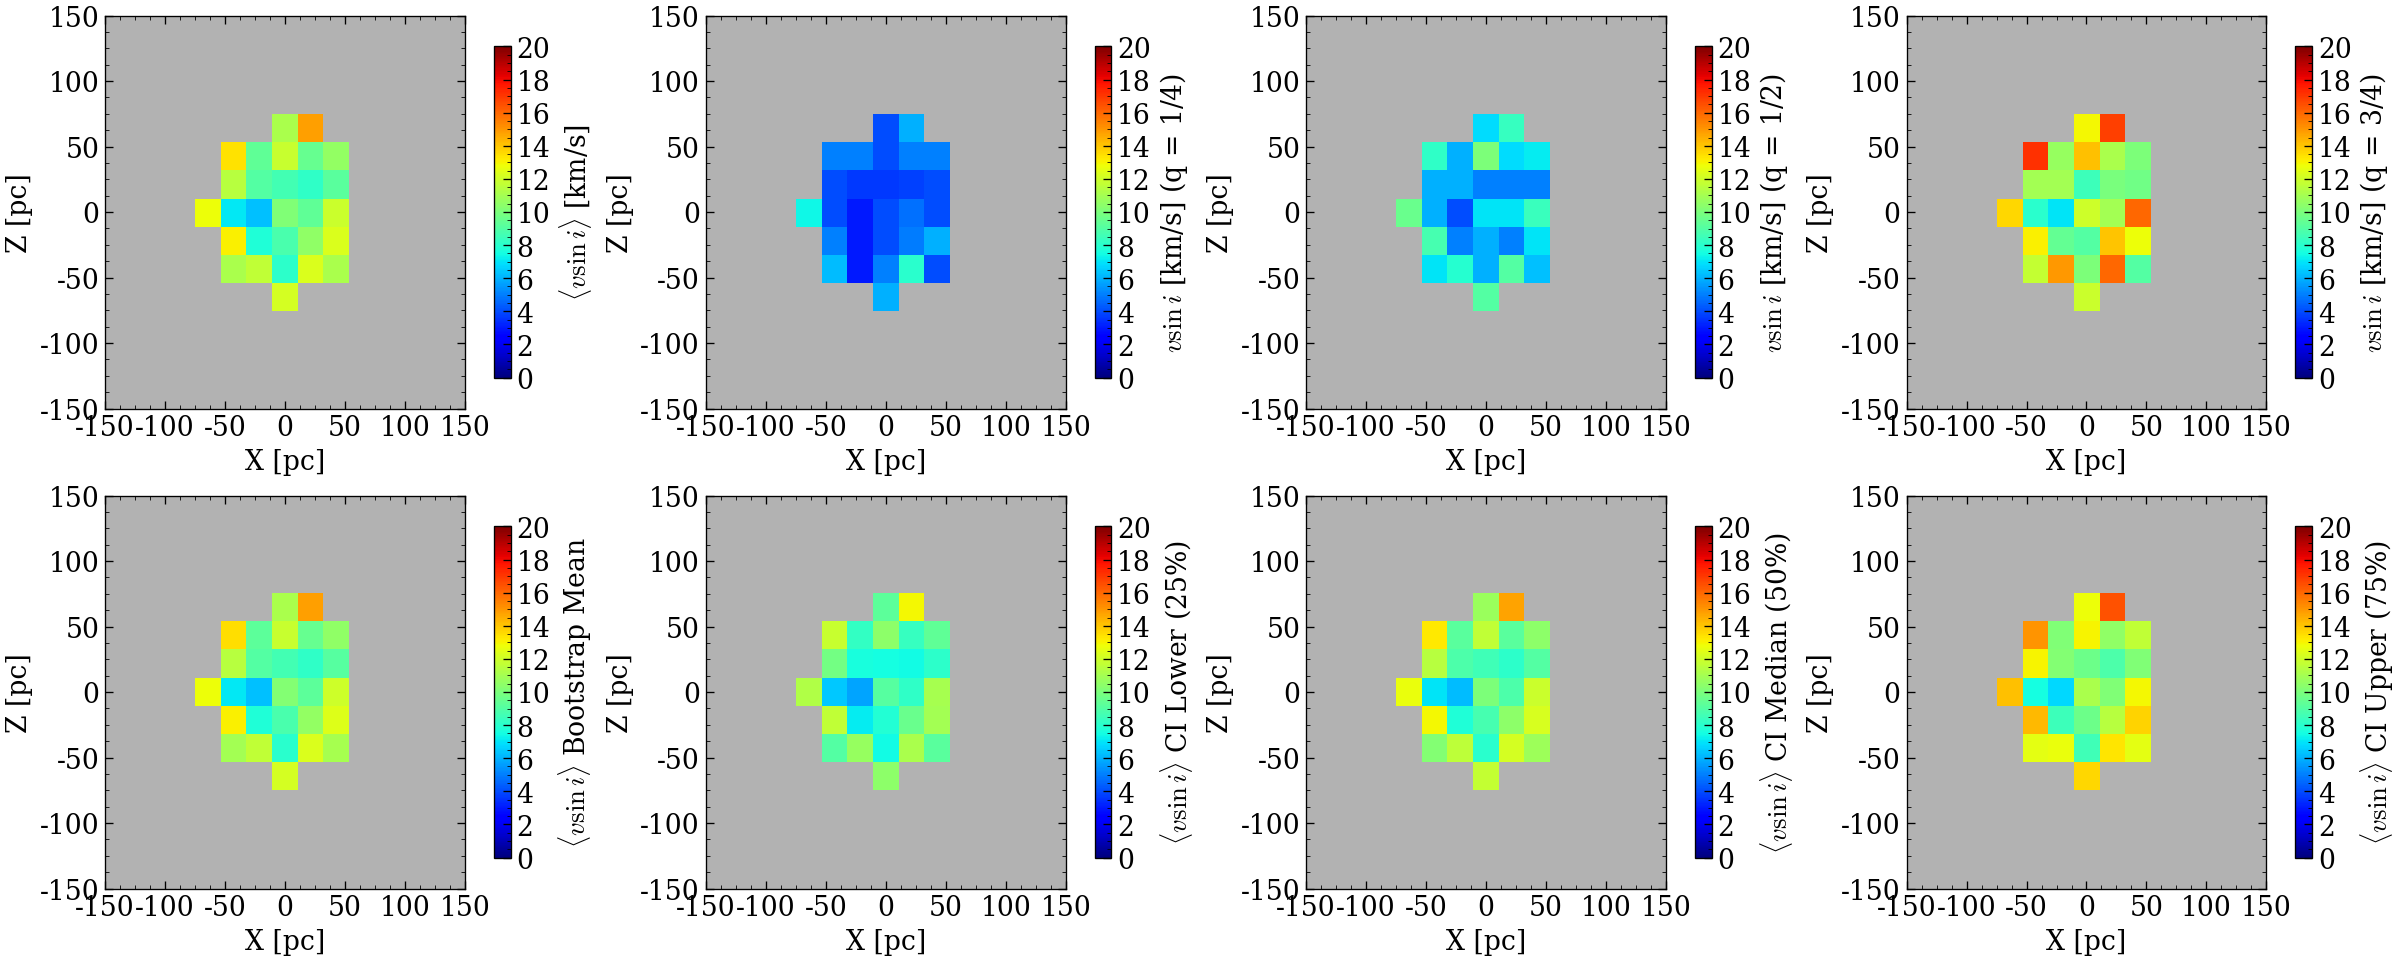

In [53]:
fig9, _ = plot_vsini_bootstrap_panel(
    original=maps_F_XZ["original"],
    bootstrap=maps_F_XZ["bootstrap"],
    plane="XZ",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=CMAP_VMAX,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig9.savefig(FIG_DIR / "vsini_F_XZ.pdf")
plt.show()

## 9. G-type stars, XY plane

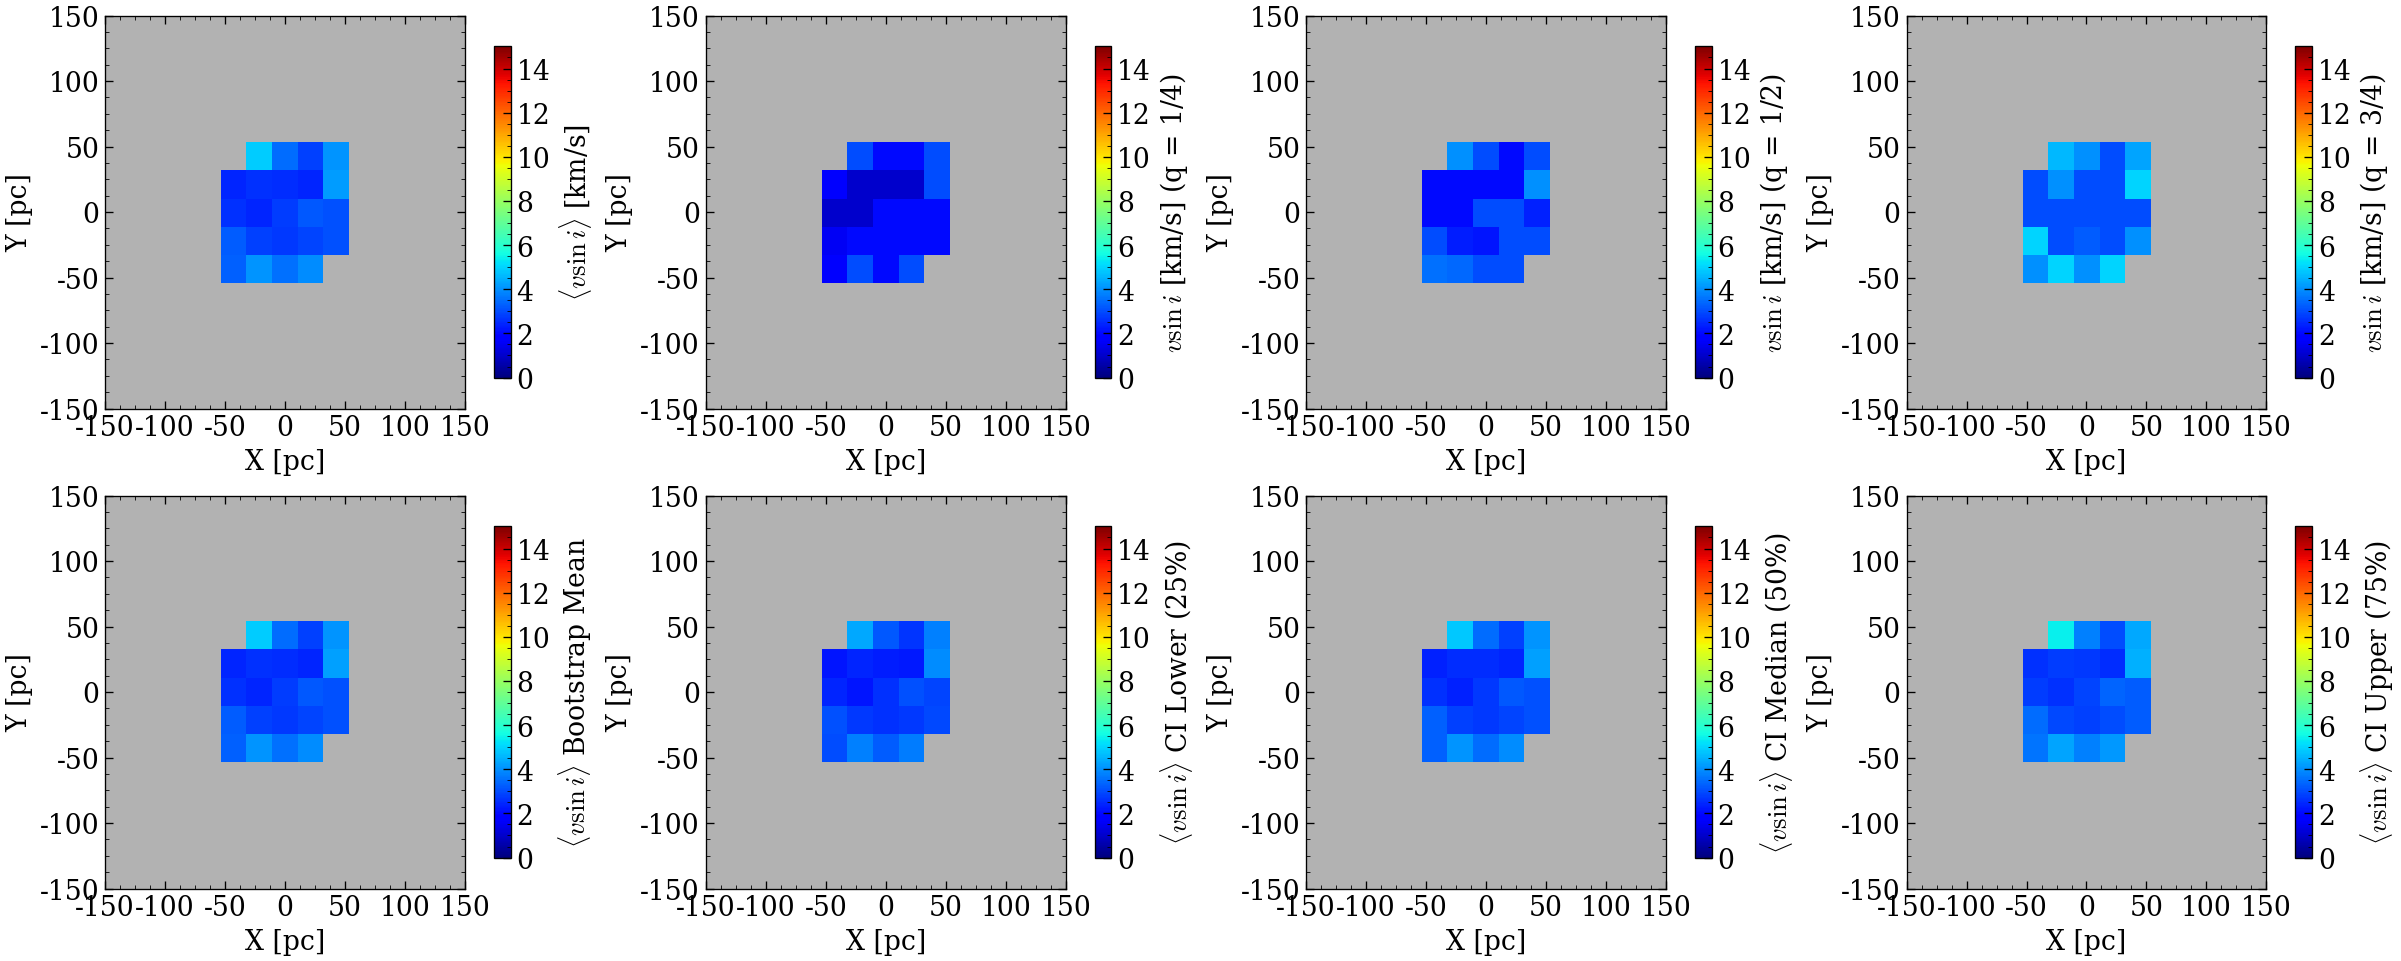

In [54]:
fig10, _ = plot_vsini_bootstrap_panel(
    original=maps_G_XY["original"],
    bootstrap=maps_G_XY["bootstrap"],
    plane="XY",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=15,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig10.savefig(FIG_DIR / "vsini_G_XY.pdf")
plt.show()

## 10. G-type stars, XZ plane

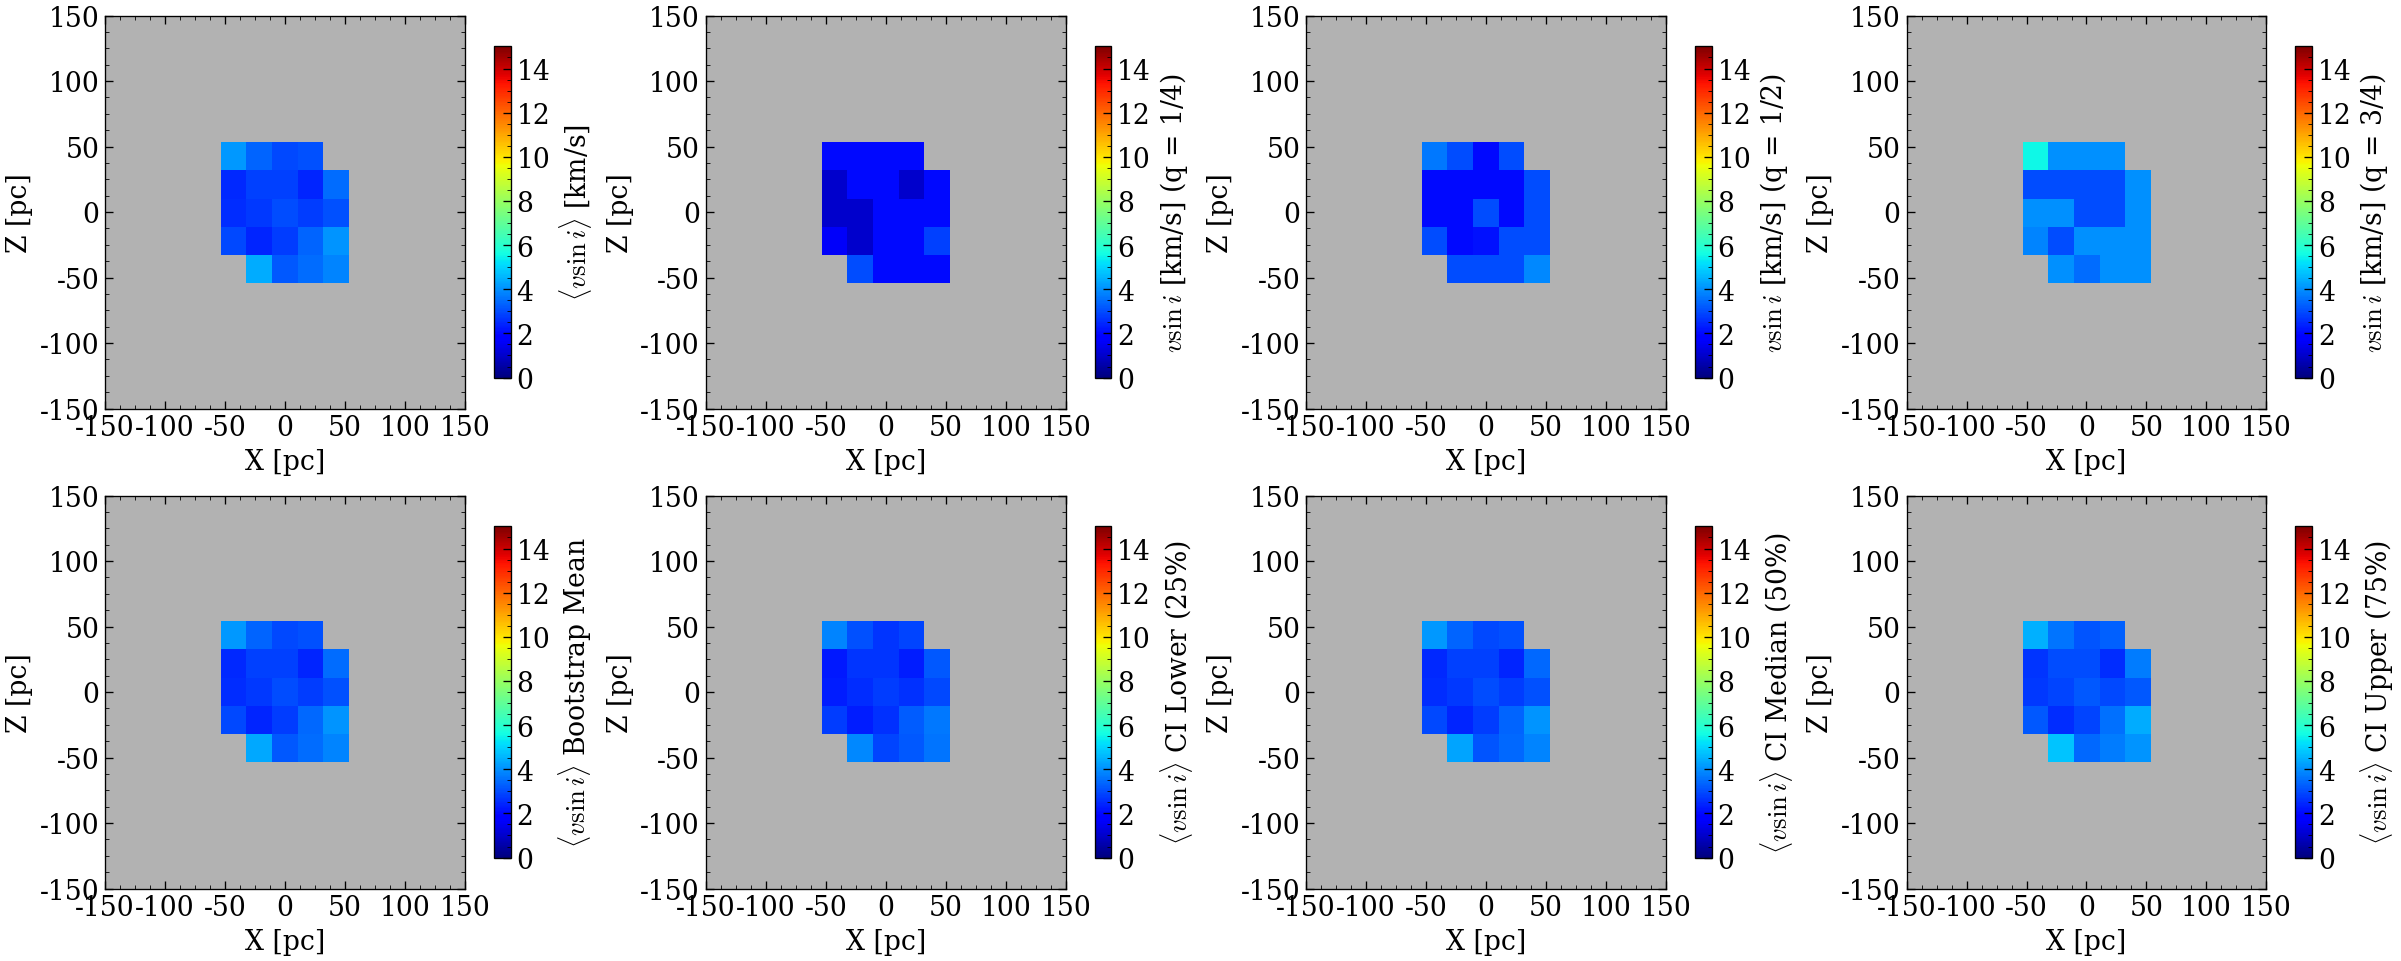

In [55]:
fig11, _ = plot_vsini_bootstrap_panel(
    original=maps_G_XZ["original"],
    bootstrap=maps_G_XZ["bootstrap"],
    plane="XZ",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=15,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig11.savefig(FIG_DIR / "vsini_G_XZ.pdf")
plt.show()

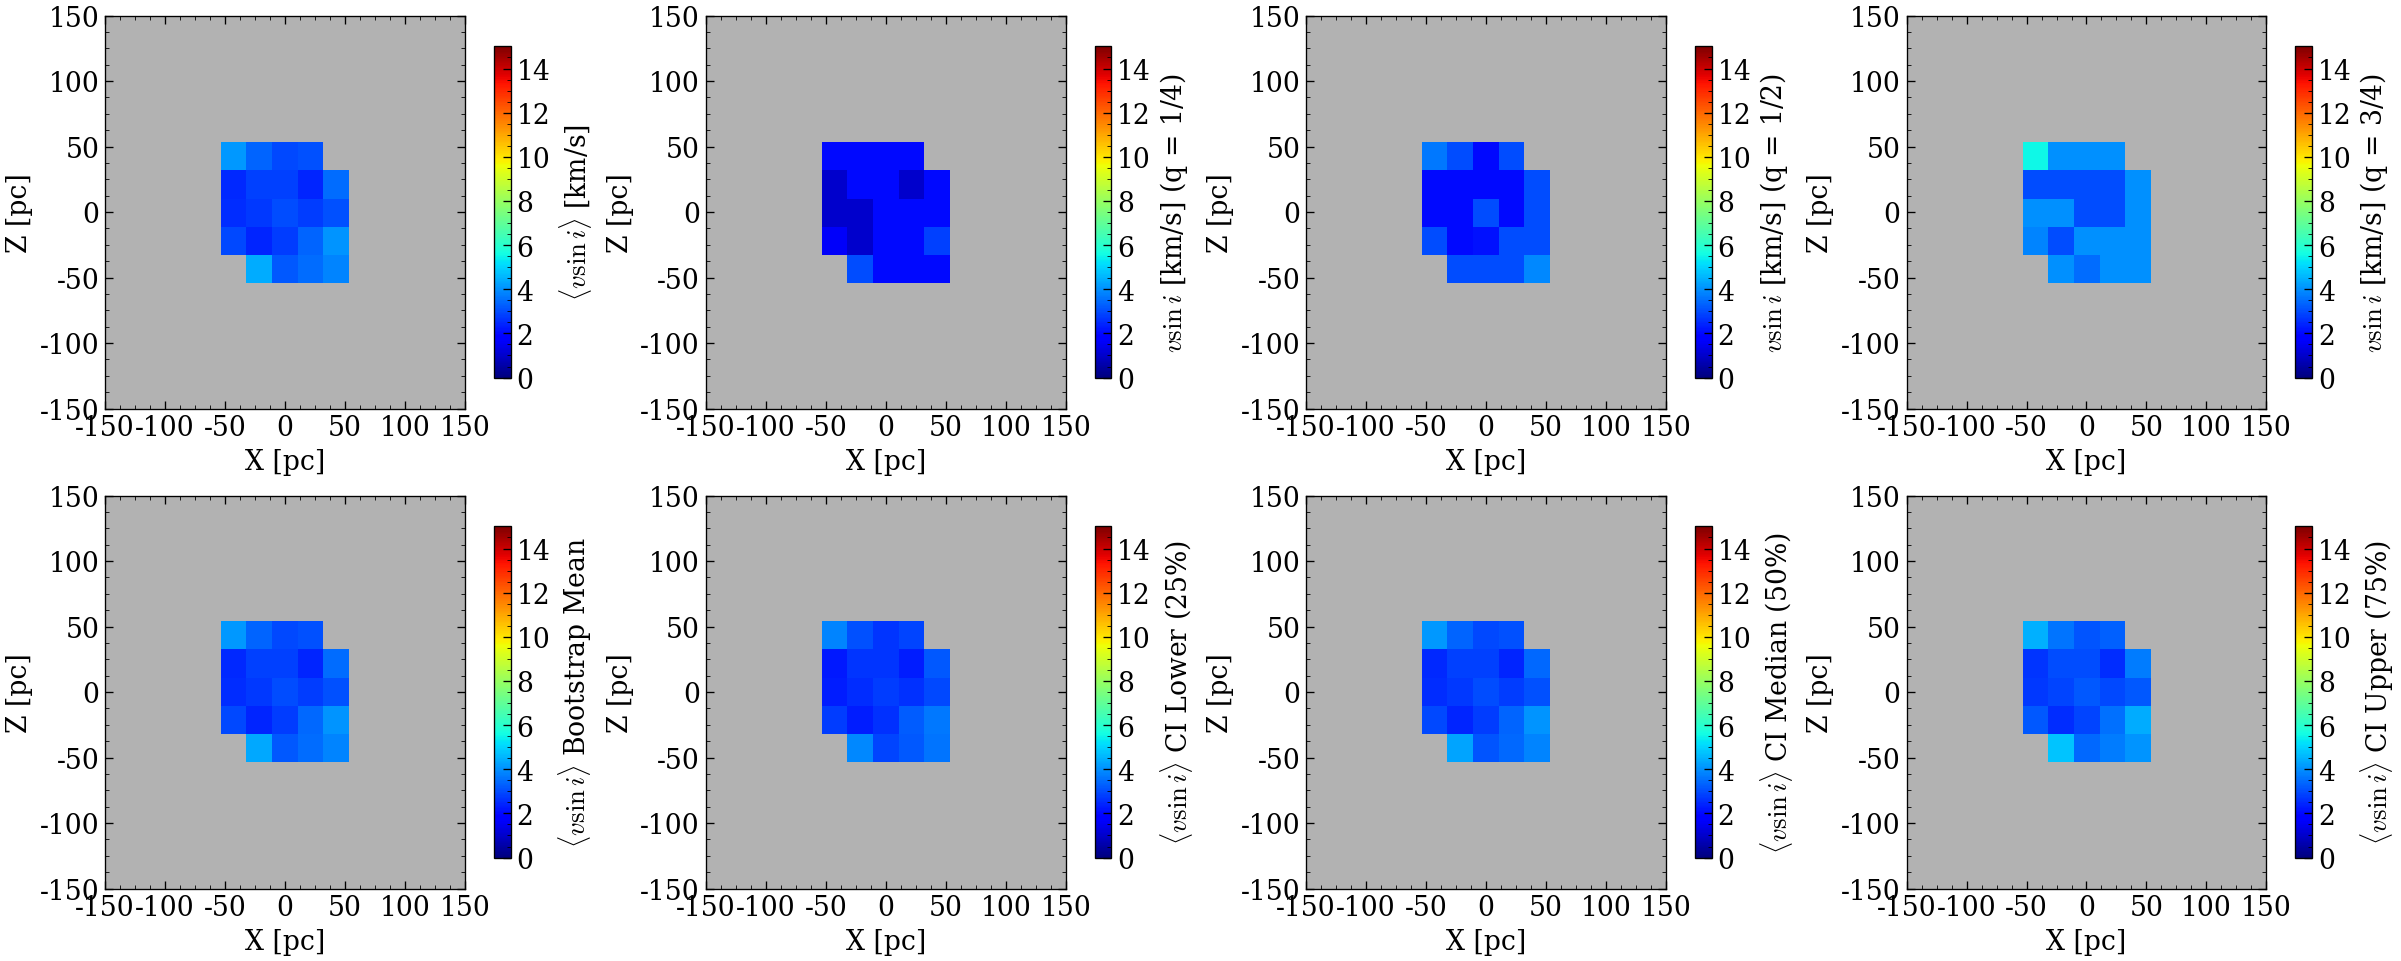

In [56]:
fig11, _ = plot_vsini_bootstrap_panel(
    original=maps_G_XZ["original"],
    bootstrap=maps_G_XZ["bootstrap"],
    plane="XZ",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=15,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig11.savefig(FIG_DIR / "vsini_G_XZ.pdf")
plt.show()

## 12. V maps

In [57]:
# print("Computing Vmag maps for ALL stars")

# vmag_all_XY = vmag_maps_for_plane(
#     df_all, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED
# )
# vmag_all_XY_ww = vmag_maps_for_plane(
#     df_all, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=False
# )

# vmag_all_XZ = vmag_maps_for_plane(
#     df_all, "XZ", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED
# )

# vmag_all_ZY = vmag_maps_for_plane(
#     df_all, "ZY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED
# )

In [58]:
# print("Vmag in XY plane (with weights)")
# fig_vmag_xy, _ = plot_vmag_bootstrap_panel(
#     original=vmag_all_XY["original"],
#     bootstrap=vmag_all_XY["bootstrap"],
#     plane="XY",
#     ul=UL,
#     method="spline16",
#     cmap="inferno",
#     vmin=VMAG_CMAP_VMIN,
#     vmax=VMAG_CMAP_VMAX,
#     raw_cells=True,
#     view_limit = 100,
# )
# fig_vmag_xy.savefig(FIG_DIR / "vmag_all_XY.pdf")
# plt.show()

# print("Vmag in XY plane (without weights)")
# fig_vmag_xy_ww, _ = plot_vmag_bootstrap_panel(
#     original=vmag_all_XY_ww["original"],
#     bootstrap=vmag_all_XY_ww["bootstrap"],
#     plane="XY",
#     ul=UL,
#     method="spline16",
#     cmap="inferno",
#     vmin=VMAG_CMAP_VMIN,
#     vmax=VMAG_CMAP_VMAX,
#     raw_cells=True,
#     view_limit = 100,
# )
# fig_vmag_xy_ww.savefig(FIG_DIR / "vmag_all_XY_without_weights.pdf")
# plt.show()

# print("Vmag in XZ plane (with weights)")
# fig_vmag_xz, _ = plot_vmag_bootstrap_panel(
#     original=vmag_all_XZ["original"],
#     bootstrap=vmag_all_XZ["bootstrap"],
#     plane="XZ",
#     ul=UL,
#     method="spline16",
#     cmap="inferno",
#     vmin=VMAG_CMAP_VMIN,
#     vmax=VMAG_CMAP_VMAX,
#     raw_cells=True,
#     view_limit = 100,
# )
# fig_vmag_xz.savefig(FIG_DIR / "vmag_all_XZ.pdf")
# plt.show()

# print("Vmag in ZY plane (with weights)")
# fig_vmag_zy, _ = plot_vmag_bootstrap_panel(
#     original=vmag_all_ZY["original"],
#     bootstrap=vmag_all_ZY["bootstrap"],
#     plane="ZY",
#     ul=UL,
#     method="spline16",
#     cmap="inferno",
#     vmin=VMAG_CMAP_VMIN,
#     vmax=VMAG_CMAP_VMAX,
#     raw_cells=True,
#     view_limit = 100,
# )
# fig_vmag_zy.savefig(FIG_DIR / "vmag_all_ZY.pdf")
# plt.show()